# Load Sentinel-3 data from the Planetary Computer STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/catalog).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

Now, we first import everything we need:

In [1]:
%%time

import xarray as xr
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 4.75 s, sys: 381 ms, total: 5.13 s
Wall time: 3.22 s


In [2]:
xr.set_options(display_expand_attrs=False)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-pc-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-pc`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [3]:
%%time
store_params = get_data_store_params_schema("stac-pc-ardc")
store_params

CPU times: user 361 ms, sys: 99.7 ms, total: 461 ms
Wall time: 460 ms


In [4]:
%%time
store = new_data_store("stac-pc-ardc")

CPU times: user 10.2 ms, sys: 5.01 ms, total: 15.2 ms
Wall time: 284 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [5]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 30 μs, sys: 3 μs, total: 33 μs
Wall time: 35.5 μs


['sentinel-2-l2a',
 'sentinel-3-synergy-syn-l2-netcdf',
 'sentinel-3-slstr-lst-l2-netcdf']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [6]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-synergy-syn-l2-netcdf")
open_params

CPU times: user 56 μs, sys: 7 μs, total: 63 μs
Wall time: 64.6 μs


The store supports the collection `"sentinel-3-synergy-syn-l2-netcdf"`, from which ARDC can be built as shown in the next cell. 

In [7]:
%%time
ds = store.open_data(
    data_id="sentinel-3-synergy-syn-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=300 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn-oa01-reflectance", "syn-oa02-reflectance"],
)
ds

CPU times: user 15.7 s, sys: 10.2 s, total: 25.8 s
Wall time: 3min 25s


<xarray.Dataset> Size: 106MB
Dimensions:       (time: 2, lat: 1114, lon: 1485)
Coordinates:
  * time          (time) datetime64[ns] 16B 2020-07-31T10:11:38.191012 2020-0...
  * lat           (lat) float64 9kB 55.0 55.0 55.0 54.99 ... 52.01 52.0 52.0
  * lon           (lon) float64 12kB 8.001 8.004 8.007 8.009 ... 12.0 12.0 12.0
    spatial_ref   int64 8B 0
Data variables:
    SDR_Oa01      (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa01_err  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa02      (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa02_err  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
Attributes: (3)

We can plot the spectral band 0 from the  OLCI Instrument as an example.

/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


CPU times: user 4.97 s, sys: 1.43 s, total: 6.4 s
Wall time: 15 s


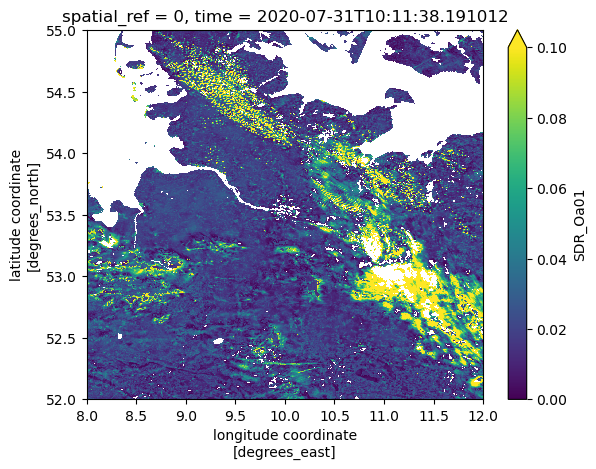

In [8]:
%%time
ds.SDR_Oa01.isel(time=-2).plot(vmin=0.0, vmax=0.1)

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-slstr-lst-l2-netcdf"`).

In [9]:
%%time
ds = store.open_data(
    data_id="sentinel-3-slstr-lst-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=300 / 111320,  # meter in degree
    crs="EPSG:4326",
)

CPU times: user 9.39 s, sys: 5.68 s, total: 15.1 s
Wall time: 1min 34s


CPU times: user 1.78 s, sys: 577 ms, total: 2.35 s
Wall time: 8.92 s


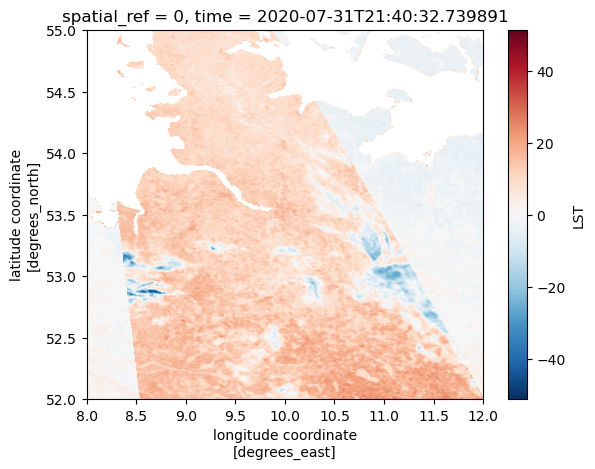

In [10]:
%%time
ds.LST.isel(time=-2).plot()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [11]:
%%time
store_params = get_data_store_params_schema("stac-pc")
store_params

CPU times: user 29 μs, sys: 13 μs, total: 42 μs
Wall time: 46 μs


To initialize the CDSE STAC data store, execute the following cell.

In [13]:
%%time
store = new_data_store("stac-pc")

CPU times: user 32.5 ms, sys: 7.57 ms, total: 40.1 ms
Wall time: 145 ms


We can search for Sentinel-3 SYN products, as shwon below:

In [15]:
search_params = store.get_search_params_schema()
search_params

In [16]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-synergy-syn-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

[{'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200705T094658_20200705T094958_0180_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.5134, 39.5428, 18.4889, 52.4499],
  'time_range': ('2020-07-05T09:46:57.969790Z',
   '2020-07-05T09:49:57.969790Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'dataset',
  'bbox': [8.3152, 39.5562, 28.3241, 52.4659],
  'time_range': ('2020-07-05T09:07:31.314318Z',
   '2020-07-05T09:10:31.314318Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200704T101309_20200704T101609_0179_060_122_2160',
  'data_type': 'dataset',
  'bbox': [-8.0581, 39.5416, 11.943, 52.4497],
  'time_range': ('2020-07-04T10:13:08.862747Z',
   '2020-07-04T10:16:08.862747Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200704T093342_20200704T093642_0179_040_364_2160',
  'data_

Below, the parameters for the `open_data` method can be viewed.

In [17]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

CPU times: user 44 μs, sys: 23 μs, total: 67 μs
Wall time: 72.2 μs


We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [18]:
%%time
ds = store.open_data(descriptors[0].data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 928 ms, sys: 450 ms, total: 1.38 s
Wall time: 5.53 s


<xarray.Dataset> Size: 2GB
Dimensions:   (y: 4091, x: 4865)
Coordinates:
    lon       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    lat       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/26)
    SDR_S1N   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2O   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3N   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3O   (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...        ...
    SDR_Oa11  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa12  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa16  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21  (y, x) float32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 755 ms, sys: 657 ms, total: 1.41 s
Wall time: 673 ms


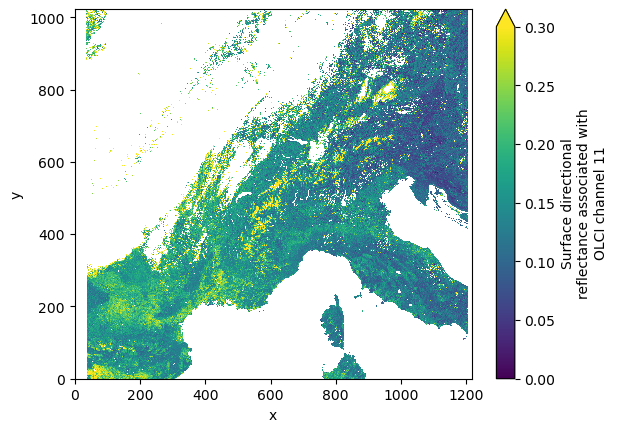

In [23]:
%%time
ds.SDR_Oa11[::4, ::4].plot(vmax=0.3, vmin=0.)

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [24]:
%%time
ds = store.open_data(descriptors[0].data_id)
ds

CPU times: user 5.34 s, sys: 5.28 s, total: 10.6 s
Wall time: 39.5 s


<xarray.Dataset> Size: 6GB
Dimensions:       (lon: 5787, lat: 5071)
Coordinates:
  * lon           (lon) float64 46kB -1.513 -1.51 -1.506 ... 18.48 18.48 18.49
  * lat           (lat) float64 41kB 52.45 52.45 52.44 ... 39.55 39.55 39.54
    spatial_ref   int64 8B 0
Data variables: (12/52)
    SDR_S1N       (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O       (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N       (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...            ...
    SDR_Oa17      (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17_err  (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18      (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18_err  (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21      (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21_err  (lat, lon) float32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 39.4 s, sys: 22.1 s, total: 1min 1s
Wall time: 29.5 s


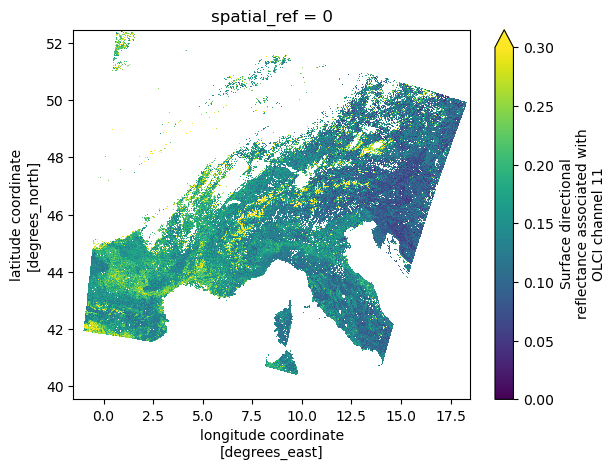

In [25]:
%%time
ds.SDR_Oa11[::4, ::4].plot(vmin=0., vmax=0.3)

The same we can do the Sentinel-3 SLSTR Land Surface Temperature

In [26]:
%%time
descriptors = list(
    store.search_data(
        collections=["sentinel-3-slstr-lst-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

CPU times: user 730 ms, sys: 607 ms, total: 1.34 s
Wall time: 6.92 s


[{'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T210953_20200705T211253_0180_060_143_0720',
  'data_type': 'dataset',
  'bbox': [-6.5275, 41.1064, 16.7602, 54.486],
  'time_range': ('2020-07-05T21:09:52.587459Z',
   '2020-07-05T21:12:52.587459Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T203026_20200705T203326_0179_040_385_0720',
  'data_type': 'dataset',
  'bbox': [3.286, 41.097, 26.5757, 54.4859],
  'time_range': ('2020-07-05T20:30:25.939839Z',
   '2020-07-05T20:33:25.939839Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T094658_20200705T094958_0179_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.7734, 39.1027, 20.6113, 52.4606],
  'time_range': ('2020-07-05T09:46:57.969633Z',
   '2020-07-05T09:49:57.969633Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'da

In [27]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

In [33]:
%%time
ds = store.open_data(descriptors[2].data_id, apply_rectification=False)
ds

CPU times: user 250 ms, sys: 200 ms, total: 451 ms
Wall time: 1.31 s


<xarray.Dataset> Size: 36MB
Dimensions:  (y: 1200, x: 1500)
Coordinates:
    lat      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST      (y, x) float32 7MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 446 ms, sys: 36.7 ms, total: 483 ms
Wall time: 349 ms


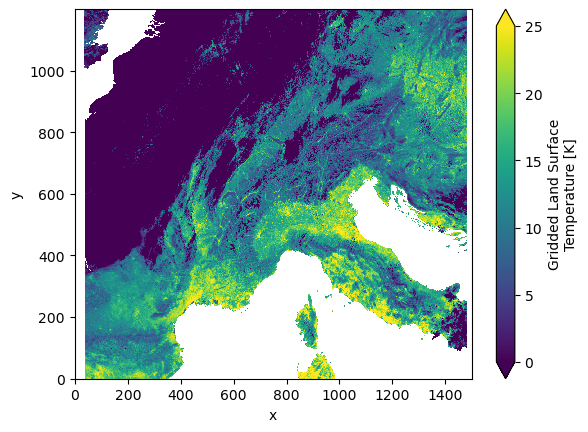

In [36]:
%%time
ds.LST.plot(vmin=0, vmax=25)

In [37]:
%%time
ds = store.open_data(descriptors[2].data_id)
ds

CPU times: user 562 ms, sys: 153 ms, total: 715 ms
Wall time: 928 ms


<xarray.Dataset> Size: 11MB
Dimensions:      (lon: 1760, lat: 1546)
Coordinates:
  * lon          (lon) float64 14kB -1.773 -1.761 -1.748 ... 20.58 20.59 20.61
  * lat          (lat) float64 12kB 52.46 52.45 52.44 52.43 ... 39.12 39.11 39.1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon) float32 11MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 5.06 s, sys: 670 ms, total: 5.73 s
Wall time: 2.07 s


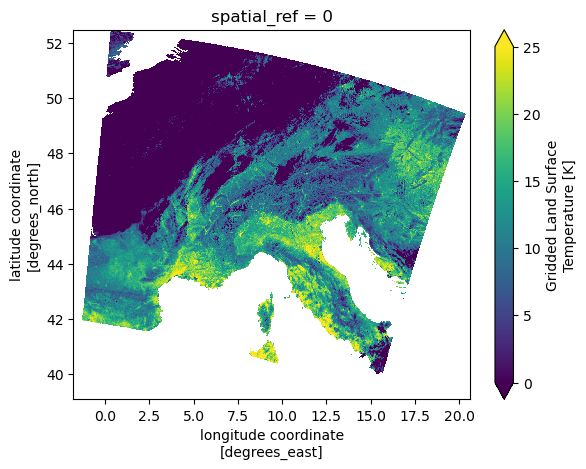

In [38]:
%%time
ds.LST.plot(vmin=0, vmax=25)